# Surface Code Implementation — Complete Workflow

## 1. Introduction to the Surface Code

* What is a surface code?
* Difference between toric code and surface code
* Why physical boundaries are introduced
* Rough and smooth boundaries
* Rotated surface code
* Distance-3 rotated surface code

## 2. Define the Surface-Code Geometry

* Construct the rotated distance-3 surface-code lattice
* Identify the 9 data qubits
* Identify the 4 X-type stabilizers
* Identify the 4 Z-type stabilizers
* Identify rough and smooth boundaries
* Visualize and label the complete lattice

## 3. Stabilizer Formalism

* Construct the X-stabilizer matrix \(H_X\)
* Construct the Z-stabilizer matrix \(H_Z\)
* Verify the commutation condition

$$
H_XH_Z^T = 0 \pmod 2
$$

* Calculate the number of logical qubits

$$
k = n - \text{rank}(H_X) - \text{rank}(H_Z)
$$

* Verify the code parameters

$$
[[9,1,3]]
$$

## 4. Logical Operators

* Identify the logical \(X_L\) operator
* Identify the logical \(Z_L\) operator
* Verify that logical operators commute with all stabilizers
* Verify that \(X_L\) and \(Z_L\) anticommute with each other

## 5. Encoding

* Construct the encoding circuit
* Prepare the logical state
* Verify the stabilizer eigenvalues
* Verify the logical state

## 6. Error Models

Study different physical errors:

* Single-qubit X error
* Single-qubit Z error
* Single-qubit Y error
* Multiple-qubit errors
* Random Pauli errors
* Depolarizing noise

## 7. Syndrome Extraction

* Introduce ancilla qubits
* Construct the X-stabilizer measurement circuits
* Construct the Z-stabilizer measurement circuits
* Measure the stabilizers
* Extract the syndrome
* Verify the syndrome for known single-qubit errors

## 8. Syndrome–Error Relationship

* Determine which stabilizers are flipped by each physical error
* Build the syndrome table
* Verify that different errors can produce the same syndrome
* Understand why decoding is required

## 9. Decoding Graph

Construct the decoding graph from the surface-code geometry.

For each error type:

* Identify syndrome defects
* Connect defects through possible error chains
* Assign edge weights based on correction distance
* Include the appropriate rough/smooth boundaries

## 10. Minimum-Weight Perfect Matching (MWPM)

* Construct the defect graph
* Calculate shortest paths between defects
* Include boundary matching
* Perform minimum-weight perfect matching
* Convert matched paths into physical correction operators

## 11. Automatic MWPM Decoder

Build an automatic decoder:

$$
\text{Syndrome}
\rightarrow
\text{Defects}
\rightarrow
\text{MWPM}
\rightarrow
\text{Correction}
$$

The decoder should work without manually specifying the error location.

## 12. Decoder Verification

Test the decoder on:

* Single-qubit errors
* Two-qubit errors
* Multiple-qubit errors
* Random error patterns

For every test:

1. Generate the error
2. Calculate the syndrome
3. Decode the syndrome
4. Apply the correction
5. Calculate the final syndrome
6. Check for a logical error

## 13. Logical Error Detection

Verify both:

* Final syndrome
* Logical operator equivalence

A zero syndrome alone does not guarantee successful decoding.

Therefore:

$$
\text{Successful decoding}
=
\text{zero final syndrome}
+
\text{no logical error}
$$

## 14. Monte Carlo Simulation

Perform a large number of random error trials for different physical error rates.

For example:

$$
p = 0.01,\;0.05,\;0.10,\;0.15,\;0.20
$$

Calculate:

* Logical success rate
* Logical error rate

$$
P_L = \frac{\text{logical failures}}{\text{total trials}}
$$

## 15. Performance Analysis

Plot:

$$
\text{Logical error rate}
\quad \text{vs.} \quad
\text{Physical error rate}
$$

Analyze how the surface-code decoder performs as the physical error rate increases.

## 16. X-Error and Z-Error Decoding

Repeat the complete decoding procedure for both error types:

### X-error decoding

$$
X\text{ errors}
\rightarrow
Z\text{-syndrome}
\rightarrow
\text{MWPM}
$$

### Z-error decoding

$$
Z\text{ errors}
\rightarrow
X\text{-syndrome}
\rightarrow
\text{MWPM}
$$

Finally, extend the decoder to handle Y errors and general Pauli noise.

## 17. Final Validation

Validate the complete surface-code implementation by checking:

* Stabilizer commutation
* Code parameters
* Logical operators
* Syndrome extraction
* Single-error correction
* Multiple-error correction
* Boundary-aware MWPM
* Logical error detection
* Monte Carlo logical error rate

## 18. Final Goal

The final implementation should demonstrate the complete QEC pipeline:

$$
\boxed{
\text{Surface Code}
\rightarrow
\text{Error}
\rightarrow
\text{Syndrome}
\rightarrow
\text{Defects}
\rightarrow
\text{MWPM}
\rightarrow
\text{Correction}
\rightarrow
\text{Logical Error Check}
}
$$

The final result will be a complete, boundary-aware rotated surface-code simulator and MWPM decoder.


In [53]:
import numpy as np
import matplotlib.pyplot as plt

d = 3
n = d**2

print("Surface Code distance:", d)
print("Number of data qubits:", n)

Surface Code distance: 3
Number of data qubits: 9


In [54]:
# Data-qubit coordinates

data_qubits = {}

for row in range(d):
    for col in range(d):
        q = row * d + col
        data_qubits[q] = (row, col)

print("Data qubit coordinates:")

for q, coord in data_qubits.items():
    print(f"q{q} -> {coord}")

Data qubit coordinates:
q0 -> (0, 0)
q1 -> (0, 1)
q2 -> (0, 2)
q3 -> (1, 0)
q4 -> (1, 1)
q5 -> (1, 2)
q6 -> (2, 0)
q7 -> (2, 1)
q8 -> (2, 2)


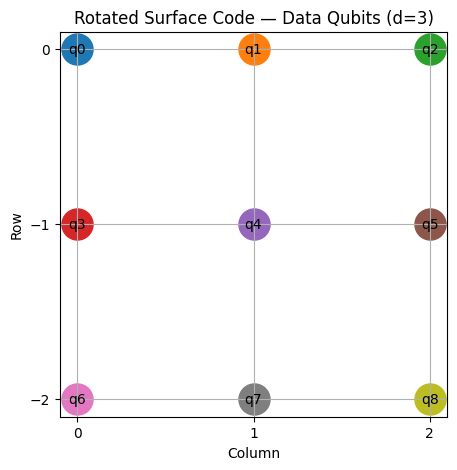

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

for q, (row, col) in data_qubits.items():
    plt.scatter(col, -row, s=500)
    plt.text(col, -row, f"q{q}", ha='center', va='center')

plt.xticks(range(d))
plt.yticks([-i for i in range(d)])
plt.grid(True)

plt.xlabel("Column")
plt.ylabel("Row")
plt.title(f"Rotated Surface Code — Data Qubits (d={d})")

plt.show()

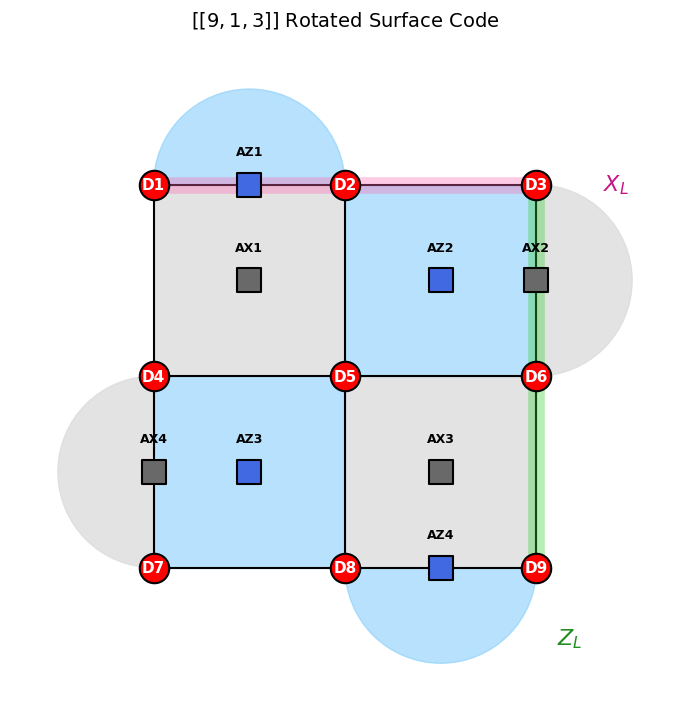

In [104]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Wedge

# CREATE FIGURE

fig, ax = plt.subplots(figsize=(7, 7))

# DATA QUBITS

data_qubits = {
    "D1": (0, 2),
    "D2": (2, 2),
    "D3": (4, 2),

    "D4": (0, 0),
    "D5": (2, 0),
    "D6": (4, 0),

    "D7": (0, -2),
    "D8": (2, -2),
    "D9": (4, -2)
}


# X STABILIZERS

# AX1 -> [D1, D2, D4, D5]
ax.add_patch(
    Polygon(
        [(0, 2), (2, 2), (2, 0), (0, 0)],
        color="gainsboro",
        alpha=0.8,
        zorder=1
    )
)

# AX3 -> [D5, D6, D8, D9]
ax.add_patch(
    Polygon(
        [(2, 0), (4, 0), (4, -2), (2, -2)],
        color="gainsboro",
        alpha=0.8,
        zorder=1
    )
)

# AX2 -> [D3, D6]
# Right boundary
ax.add_patch(
    Wedge(
        (4, 1),
        1,
        270,
        90,
        color="gainsboro",
        alpha=0.8,
        zorder=1
    )
)

# AX4 -> [D4, D7]
# Left boundary
ax.add_patch(
    Wedge(
        (0, -1),
        1,
        90,
        270,
        color="gainsboro",
        alpha=0.8,
        zorder=1
    )
)


# Z STABILIZERS

# AZ2 -> [D2, D3, D5, D6]
ax.add_patch(
    Polygon(
        [(2, 2), (4, 2), (4, 0), (2, 0)],
        color="lightskyblue",
        alpha=0.6,
        zorder=1
    )
)

# AZ3 -> [D4, D5, D7, D8]
ax.add_patch(
    Polygon(
        [(0, 0), (2, 0), (2, -2), (0, -2)],
        color="lightskyblue",
        alpha=0.6,
        zorder=1
    )
)

# AZ1 -> [D1, D2]
# Top boundary
ax.add_patch(
    Wedge(
        (1, 2),
        1,
        0,
        180,
        color="lightskyblue",
        alpha=0.6,
        zorder=1
    )
)

# AZ4 -> [D8, D9]
# Bottom boundary
ax.add_patch(
    Wedge(
        (3, -2),
        1,
        180,
        360,
        color="lightskyblue",
        alpha=0.6,
        zorder=1
    )
)


# GRID

for x in [0, 2, 4]:
    ax.plot(
        [x, x],
        [-2, 2],
        color="black",
        linewidth=1.5,
        zorder=2
    )

for y in [-2, 0, 2]:
    ax.plot(
        [0, 4],
        [y, y],
        color="black",
        linewidth=1.5,
        zorder=2
    )


# DATA QUBIT CIRCLES

for name, (x, y) in data_qubits.items():

    ax.scatter(
        x,
        y,
        color="red",
        s=450,
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    ax.text(
        x,
        y,
        name,
        color="white",
        fontsize=11,
        weight="bold",
        ha="center",
        va="center",
        zorder=6
    )


# ANCILLA QUBITS

ancilla_qubits = {

    # X-type
    "AX1": (1, 1),
    "AX2": (4, 1),
    "AX3": (3, -1),
    "AX4": (0, -1),

    # Z-type
    "AZ1": (1, 2),
    "AZ2": (3, 1),
    "AZ3": (1, -1),
    "AZ4": (3, -2)
}


# X ANCILLAS

for name in ["AX1", "AX2", "AX3", "AX4"]:

    x, y = ancilla_qubits[name]

    ax.scatter(
        x,
        y,
        color="dimgrey",
        marker="s",
        s=300,
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    ax.text(
        x,
        y + 0.28,
        name,
        fontsize=9,
        weight="bold",
        ha="center",
        va="bottom",
        zorder=6
    )


# Z ANCILLAS

for name in ["AZ1", "AZ2", "AZ3", "AZ4"]:

    x, y = ancilla_qubits[name]

    ax.scatter(
        x,
        y,
        color="royalblue",
        marker="s",
        s=300,
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    ax.text(
        x,
        y + 0.28,
        name,
        fontsize=9,
        weight="bold",
        ha="center",
        va="bottom",
        zorder=6
    )


# LOGICAL OPERATORS

# Logical X: D1 -> D2 -> D3
ax.plot(
    [0, 4],
    [2, 2],
    color="hotpink",
    linewidth=12,
    alpha=0.35,
    zorder=3
)

ax.text(
    4.7,
    2,
    "$X_L$",
    color="mediumvioletred",
    fontsize=16,
    weight="bold",
    va="center"
)


# Logical Z: D3 -> D6 -> D9
ax.plot(
    [4, 4],
    [2, -2],
    color="limegreen",
    linewidth=12,
    alpha=0.35,
    zorder=3
)

ax.text(
    4.35,
    -2.8,
    "$Z_L$",
    color="forestgreen",
    fontsize=16,
    weight="bold",
    ha="center"
)


# FINAL SETTINGS

ax.set_title(
    "$[[9,1,3]]$ Rotated Surface Code",
    fontsize=14,
    pad=25
)

ax.set_xlim(-1.5, 5.5)
ax.set_ylim(-3.3, 3.3)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

In [58]:
# 3x3 Rotated Surface Code (d = 3)
# Data-qubit numbering:
#
# D1 --- D2 --- D3
# |      |      |
# D4 --- D5 --- D6
# |      |      |
# D7 --- D8 --- D9

d = 3

# X-type stabilizers
# X1: top-left grey internal face, weight-4
# X2: right boundary, weight-2
# X3: Bottom-right grey internal face, weight-4
# X4: left boundary, weight-2


# Z-type stabilizers
# Z1: Right-top boundary, weight-2
# Z2: Top-right blue plaquette , weight-4
# Z3: Bottom-left blue plaquette, weight-4
# Z4: bottom boundary, weight-2

# X-type stabilizers
X_stabilizers = {
    "X1": [1, 2, 4, 5],   # top-left grey plaquette
    "X2": [3,6],          # right boundary
    "X3": [5, 6, 8, 9],   # bottom-right grey plaquette
    "X4": [4, 7]          # left boundary
}

# Z-type stabilizers
Z_stabilizers = {
    "Z1": [1, 2],         # top boundary
    "Z2": [2, 3, 5, 6],   # top-right blue plaquette
    "Z3": [4, 5, 7, 8],   # bottom-left blue plaquette
    "Z4": [8, 9]          # bottom boundary
}
# Print the stabilizers
print("X-type stabilizers:")
for name, qubits in X_stabilizers.items():
    print(f"{name} -> {qubits}")

print("\nZ-type stabilizers:")
for name, qubits in Z_stabilizers.items():
    print(f"{name} -> {qubits}")

X-type stabilizers:
X1 -> [1, 2, 4, 5]
X2 -> [3, 6]
X3 -> [5, 6, 8, 9]
X4 -> [4, 7]

Z-type stabilizers:
Z1 -> [1, 2]
Z2 -> [2, 3, 5, 6]
Z3 -> [4, 5, 7, 8]
Z4 -> [8, 9]


## Rough and Smooth Boundaries

In the rotated surface code, the physical boundaries are divided into two types: **rough boundaries** and **smooth boundaries**.

For the convention used in this implementation:

### Rough Boundaries

The **left and right boundaries** are the rough boundaries.

* Left rough boundary → `X4 = [D4, D7]`
* Right rough boundary → `X2 = [D3, D6]`

These are the **weight-2 X-type boundary stabilizers**.

### Smooth Boundaries

The **top and bottom boundaries** are the smooth boundaries.

* Top smooth boundary → `Z1 = [D1, D2]`
* Bottom smooth boundary → `Z4 = [D8, D9]`

These are the **weight-2 Z-type boundary stabilizers**.

### Boundary Summary

| Boundary | Location | Stabilizer | Type   |
| -------- | -------- | ---------- | ------ |
| Left     | D4–D7    | X4         | Rough  |
| Right    | D3–D6    | X2         | Rough  |
| Top      | D1–D2    | Z1         | Smooth |
| Bottom   | D8–D9    | Z4         | Smooth |

These boundaries are important for decoding because an error string can terminate at the appropriate boundary instead of always being paired with another syndrome defect.


## Surface Code vs Toric Code

The surface code is closely related to the toric code, but the two codes have an important geometric difference.

### Toric Code

* The lattice has **periodic boundary conditions**.
* The lattice effectively wraps around in both directions.
* There are no physical boundaries.
* Error strings form closed loops or non-contractible loops around the torus.

### Surface Code

* The lattice has **physical boundaries**.
* The lattice does not wrap around.
* There are two types of boundaries: **rough** and **smooth**.
* Error strings can terminate at the appropriate physical boundary.
* This makes the surface code more suitable for practical implementations.

In this project, we use a **rotated distance-3 surface code** with:

* 9 data qubits
* 4 X-type stabilizers
* 4 Z-type stabilizers
* 1 logical qubit

Therefore, the code has parameters:

$$
[[9,1,3]]
$$

The physical boundaries are explicitly included in the geometry and will later be used when constructing the decoding graph.


In [59]:
import numpy as np

# Number of data qubits
n = d**2

# Construct HX
HX = np.zeros((len(X_stabilizers), n), dtype=int)

for i, qubits in enumerate(X_stabilizers.values()):
    for q in qubits:
        HX[i, q - 1] = 1

# Construct HZ
HZ = np.zeros((len(Z_stabilizers), n), dtype=int)
for i, qubits in enumerate(Z_stabilizers.values()):
    for q in qubits:
        HZ[i, q - 1] = 1

# Print matrices
print("HX =")
print(HX)

print("\nHZ =")
print(HZ)

HX =
[[1 1 0 1 1 0 0 0 0]
 [0 0 1 0 0 1 0 0 0]
 [0 0 0 0 1 1 0 1 1]
 [0 0 0 1 0 0 1 0 0]]

HZ =
[[1 1 0 0 0 0 0 0 0]
 [0 1 1 0 1 1 0 0 0]
 [0 0 0 1 1 0 1 1 0]
 [0 0 0 0 0 0 0 1 1]]


In [60]:
# Check X-Z commutation
commutation = (HX @ HZ.T) % 2

print("HX @ HZ.T mod 2 =")
print(commutation)

if np.all(commutation == 0):
    print("\n All X and Z stabilizers commute.")
else:
    print("\n Some X and Z stabilizers do NOT commute.")

HX @ HZ.T mod 2 =
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

 All X and Z stabilizers commute.


In [61]:
def gf2_rank(matrix):
    matrix = matrix.copy() % 2
    rows, cols = matrix.shape

    rank = 0

    for col in range(cols):
        # Find a row with 1 in this column
        pivot = None

        for row in range(rank, rows):
            if matrix[row, col] == 1:
                pivot = row
                break

        if pivot is None:
            continue

        # Swap pivot row with current rank row
        matrix[[rank, pivot]] = matrix[[pivot, rank]]

        # Eliminate this column from all other rows
        for row in range(rows):
            if row != rank and matrix[row, col] == 1:
                matrix[row] = (matrix[row] + matrix[rank]) % 2

        rank += 1

    return rank


rank_H = gf2_rank(H)

n = 9
k = n - rank_H

print("Number of physical qubits:", n)
print("Rank of stabilizer matrix:", rank_H)
print("Number of logical qubits:", k)

Number of physical qubits: 9
Rank of stabilizer matrix: 8
Number of logical qubits: 1


## Code Parameters and Distance

The rotated surface code contains 9 physical data qubits and encodes 1 logical qubit.
For a CSS quantum error-correcting code, the code distance is given by

d = min(d_X, d_Z)

where:

- d_x is the minimum weight of a non-trivial logical $X$ operator.
- d_z is the minimum weight of a non-trivial logical $Z$ operator.

For the d=3 rotated Surface Code, we find:

The minimum weight of a nontrivial logical \(X\) operator is 3, and the minimum weight of a nontrivial logical \(Z\) operator is also 3.

Therefore, the code distance is

d_x = 3

and

d_z = 3


Therefore,

d = min(3,3) = 3

The stabilizer analysis gives:

$$
n = 9,\qquad k = 1.
$$

Hence, the constructed code is a
[[9,1,3]] code.

This means that the code encodes **1 logical qubit into 9 physical qubits** and can detect up to **2 errors** and correct **1 arbitrary single-qubit error**.

The chosen logical operators are

$$
X_L = X_1X_2X_3
$$

and

$$
Z_L = Z_3Z_6Z_9.
$$

Equivalent logical representatives can also be obtained by multiplying these operators by stabilizers. For example, \(Z_1Z_4Z_7\) is another minimum-weight representative of the same logical \(Z\) operator.


## Logical Operators:

In [62]:
import numpy as np
# Logical X and Z operators
logical_X = [1, 2, 3]
logical_Z = [3, 6, 9]

# Convert to binary vectors
x_logical = np.zeros(9, dtype=int)
z_logical = np.zeros(9, dtype=int)

for q in logical_X:
    x_logical[q - 1] = 1

for q in logical_Z:
    z_logical[q - 1] = 1

print("Logical X:", x_logical)
print("Logical Z:", z_logical)

Logical X: [1 1 1 0 0 0 0 0 0]
Logical Z: [0 0 1 0 0 1 0 0 1]


In [63]:
# Check logical X with all Z stabilizers
logical_X_with_Z = (HZ @ x_logical) % 2

# Check logical Z with all X stabilizers
logical_Z_with_X = (HX @ z_logical) % 2

print("Z stabilizers vs Logical X:")
print(logical_X_with_Z)

print("\nX stabilizers vs Logical Z:")
print(logical_Z_with_X)

Z stabilizers vs Logical X:
[0 0 0 0]

X stabilizers vs Logical Z:
[0 0 0 0]


In [64]:
# Check Logical X and Logical Z commutation
logical_commutation = np.dot(x_logical, z_logical) % 2

print("Logical X · Logical Z mod 2 =", logical_commutation)

if logical_commutation == 1:
    print(" Logical X and Logical Z anticommute")
else:
    print(" Logical X and Logical Z commute")

Logical X · Logical Z mod 2 = 1
 Logical X and Logical Z anticommute


In [65]:
#X-type logical distance
from itertools import combinations

def binary_vector(qubits, n=9):
    v = np.zeros(n, dtype=int)
    for q in qubits:
        v[q - 1] = 1
    return v


# Generate all X-type operators that commute with Z stabilizers
valid_X = []

for weight in range(1, 10):
    for qubits in combinations(range(1, 10), weight):
        x = binary_vector(qubits)

        # Must commute with all Z stabilizers
        if np.all((HZ @ x) % 2 == 0):
            valid_X.append((weight, qubits))


print("First few valid X operators:")
print(valid_X[:10])

First few valid X operators:
[(2, (3, 6)), (2, (4, 7)), (3, (1, 2, 3)), (3, (1, 2, 6)), (3, (3, 4, 5)), (3, (3, 5, 7)), (3, (4, 5, 6)), (3, (4, 8, 9)), (3, (5, 6, 7)), (3, (7, 8, 9))]


In [66]:
# Generate all combinations of X stabilizer generators
X_stabilizer_space = set()

for mask in range(2 ** len(X_stabilizers)):
    vector = np.zeros(9, dtype=int)

    for i in range(len(X_stabilizers)):
        if (mask >> i) & 1:
            vector ^= HX[i]

    X_stabilizer_space.add(tuple(vector))


# Find minimum-weight X operator
# that commutes with Z stabilizers but is NOT an X stabilizer
logical_X_candidates = []

for weight, qubits in valid_X:
    x = binary_vector(qubits)

    if tuple(x) not in X_stabilizer_space:
        logical_X_candidates.append((weight, qubits))

# Find minimum-weight nontrivial X logical
minimum_X_logical = min(logical_X_candidates, key=lambda x: x[0])
print("Minimum-weight nontrivial X logical:")
print(logical_X_candidates[0])

Minimum-weight nontrivial X logical:
(3, (1, 2, 3))


In [67]:
# Z-type logical distance
# Generate all combinations of Z stabilizer generators
Z_stabilizer_space = set()

for mask in range(2 ** len(Z_stabilizers)):
    vector = np.zeros(9, dtype=int)

    for i in range(len(Z_stabilizers)):
        if (mask >> i) & 1:
            vector ^= HZ[i]

    Z_stabilizer_space.add(tuple(vector))


# Find Z operators commuting with all X stabilizers
valid_Z = []

for weight in range(1, 10):
    for qubits in combinations(range(1, 10), weight):
        z = binary_vector(qubits)

        if np.all((HX @ z) % 2 == 0):
            valid_Z.append((weight, qubits))


# Remove stabilizers
logical_Z_candidates = []

for weight, qubits in valid_Z:
    z = binary_vector(qubits)

    if tuple(z) not in Z_stabilizer_space:
        logical_Z_candidates.append((weight, qubits))

# Find minimum-weight Z logical
minimum_Z_logical = min(logical_Z_candidates, key=lambda x: x[0])
print("Minimum-weight nontrivial Z logical:")
print(logical_Z_candidates[0])

Minimum-weight nontrivial Z logical:
(3, (1, 4, 7))


In [68]:
# Calculate X and Z distances

d_X = minimum_X_logical[0]
d_Z = minimum_Z_logical[0]

# Code distance
code_distance = min(d_X, d_Z)

print("d_X =", d_X)
print("d_Z =", d_Z)
print("Code distance d =", code_distance)

d_X = 3
d_Z = 3
Code distance d = 3


In [69]:
# Surface Code parameters

print("Surface Code parameters:")
print(f"[[{n}, {k}, {code_distance}]]")

Surface Code parameters:
[[9, 1, 3]]


## Encoding the Logical \(|0_L\rangle\)

The surface code encodes one logical qubit into nine physical data qubits.

To construct an encoded logical zero state, we prepare a state \(|0_L\rangle\) that satisfies

$$
S_i|0_L\rangle = |0_L\rangle
$$

for every stabilizer \(S_i\).

In addition, the logical \(Z\) operator must satisfy

$$
Z_L|0_L\rangle = |0_L\rangle.
$$

Therefore, the encoded state is the simultaneous \(+1\) eigenstate of:

* all four X-type stabilizers,
* all four Z-type stabilizers,
* the logical \(Z_L\) operator.

Since there are 9 physical qubits and 8 independent stabilizers, one logical degree of freedom remains. Fixing the eigenvalue of \(Z_L\) to \(+1\) selects the logical \(|0_L\rangle\) state.


In [18]:
!pip install qiskit

In [70]:
import qiskit

print("Qiskit version:", qiskit.__version__)

Qiskit version: 2.5.2


In [71]:
from qiskit import QuantumCircuit

# 9 physical data qubits
qc = QuantumCircuit(9, 9)

# Put the logical input on q0
# For |0>_L, q0 is already |0>
# For |1>_L, we would apply X to q0

print(qc)

     
q_0: 
     
q_1: 
     
q_2: 
     
q_3: 
     
q_4: 
     
q_5: 
     
q_6: 
     
q_7: 
     
q_8: 
     
c: 9/
     


## Encoding the Logical |0_L⟩ State

We prepare the logical |0_L⟩ state by starting with four independent
physical qubits in the |+⟩ state and then using CNOT gates to generate
the superposition corresponding to the X-stabilizer space.

The four independent qubits are D1, D3, D4 and D5.

The resulting state is stabilized by all four X-type stabilizers,
all four Z-type stabilizers, and the logical Z operator.

Therefore, the circuit prepares the logical |0_L⟩ state.

In [72]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(9, 9)

# Step 1: Create superposition on 4 independent qubits
qc.h(0)   # D1
qc.h(2)   # D3
qc.h(3)   # D4
qc.h(4)   # D5

# Step 2: Spread the information using CNOTs

# v1 = D1 D2 D6 D7 D8 D9
qc.cx(0, 1)   # D1 -> D2
qc.cx(0, 5)   # D1 -> D6
qc.cx(0, 6)   # D1 -> D7
qc.cx(0, 7)   # D1 -> D8
qc.cx(0, 8)   # D1 -> D9

# v2 = D3 D6
qc.cx(2, 5)   # D3 -> D6

# v3 = D4 D7
qc.cx(3, 6)   # D4 -> D7

# v4 = D5 D6 D8 D9
qc.cx(4, 5)   # D5 -> D6
qc.cx(4, 7)   # D5 -> D8
qc.cx(4, 8)   # D5 -> D9

print(qc)

     ┌───┐                                                  
q_0: ┤ H ├──■────■────■─────────■──────────────■────────────
     └───┘┌─┴─┐  │    │         │              │            
q_1: ─────┤ X ├──┼────┼─────────┼──────────────┼────────────
     ┌───┐└───┘  │    │         │              │            
q_2: ┤ H ├───────┼────┼────■────┼──────────────┼────────────
     ├───┤       │    │    │    │              │            
q_3: ┤ H ├───────┼────┼────┼────┼────■─────────┼────────────
     ├───┤       │    │    │    │    │         │            
q_4: ┤ H ├───────┼────┼────┼────┼────┼────■────┼────■────■──
     └───┘     ┌─┴─┐  │  ┌─┴─┐  │    │  ┌─┴─┐  │    │    │  
q_5: ──────────┤ X ├──┼──┤ X ├──┼────┼──┤ X ├──┼────┼────┼──
               └───┘┌─┴─┐└───┘  │  ┌─┴─┐└───┘  │    │    │  
q_6: ───────────────┤ X ├───────┼──┤ X ├───────┼────┼────┼──
                    └───┘     ┌─┴─┐└───┘       │  ┌─┴─┐  │  
q_7: ─────────────────────────┤ X ├────────────┼──┤ X ├──┼──
                        

In [73]:
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)

print(state)

Statevector([0.25+0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.25+0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.25+0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.25+0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.25+0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j

In [ ]:
# Convert Stabilizers into Pauli operators

### Qiskit Pauli-String Convention

In this implementation, the physical data qubits are labeled as \(D1,D2,\ldots,D9\), corresponding to Qiskit qubits \(q_0,q_1,\ldots,q_8\).

When using `qiskit.quantum_info.Pauli`, the Pauli string is written in **reverse qubit order**:

$$
q_8,q_7,\ldots,q_1,q_0
$$

Therefore, the **leftmost character corresponds to the highest-index Qiskit qubit**, while the **rightmost character corresponds to \(q_0\) (D1)**.

For example,

$$
Z_{D1}Z_{D2}
$$

is represented in Qiskit as:

```python
Pauli("IIIIIII ZZ".replace(" ", ""))
```

because the \(Z\) operators act on \(q_1\) and \(q_0\).

To avoid indexing mistakes, the Pauli strings in this project are generated automatically from the physical data-qubit labels \(D1-D9\).


In [ ]:
from qiskit.quantum_info import Pauli

# Stabilizers in Qiskit Pauli-string convention

X_stabilizers = [

    Pauli("IIIIXXIXI"),   # X1 = D1 D2 D4 D5
    Pauli("IIXIIIXII"),   # X2 = D3 D6
    Pauli("XXIXXIIII"),   # X3 = D5 D6 D8 D9
    Pauli("IIIXIIIXI")    # X4 = D4 D7

]

Z_stabilizers = [

    Pauli("IIIIIII ZZ".replace(" ", "")),   # Z1 = D1 D2
    Pauli("IIIZZIZZ I".replace(" ", "")),   # Z2 = D2 D3 D5 D6
    Pauli("I ZZ I ZZ I".replace(" ", "")),  # Z3 = D4 D5 D7 D8
    Pauli("ZZIIIIIII")                       # Z4 = D8 D9

]

logical_Z = Pauli("IIZIIZIIZ")

In [75]:
def pauli_from_qubits(qubits, pauli_type, n=9):
    """
    Create a Qiskit Pauli string from D1...Dn numbering.

    Qiskit convention:
    leftmost character = highest-index qubit
    rightmost character = D1
    """

    labels = ["I"] * n

    for q in qubits:
        labels[q - 1] = pauli_type

    # Reverse because Qiskit Pauli strings are q_(n-1) ... q_0
    return Pauli("".join(labels[::-1]))


X_stabilizers = [
    pauli_from_qubits([1, 2, 4, 5], "X"),
    pauli_from_qubits([3, 6], "X"),
    pauli_from_qubits([5, 6, 8, 9], "X"),
    pauli_from_qubits([4, 7], "X")
]

Z_stabilizers = [
    pauli_from_qubits([1, 2], "Z"),
    pauli_from_qubits([2, 3, 5, 6], "Z"),
    pauli_from_qubits([4, 5, 7, 8], "Z"),
    pauli_from_qubits([8, 9], "Z")
]

logical_Z = pauli_from_qubits([3, 6, 9], "Z")


print("X stabilizers:")
for i, S in enumerate(X_stabilizers):
    print(f"X{i+1} =", S)

print("\nZ stabilizers:")
for i, S in enumerate(Z_stabilizers):
    print(f"Z{i+1} =", S)

print("\nLogical Z =", logical_Z)

X stabilizers:
X1 = IIIIXXIXX
X2 = IIIXIIXII
X3 = XXIXXIIII
X4 = IIXIIXIII

Z stabilizers:
Z1 = IIIIIIIZZ
Z2 = IIIZZIZZI
Z3 = IZZIZZIII
Z4 = ZZIIIIIII

Logical Z = ZIIZIIZII


In [76]:
def check_stabilizer(state, operator):
    new_state = state.evolve(operator)
    
    overlap = state.inner(new_state)
    
    return round(overlap.real, 6)

for i, S in enumerate(X_stabilizers):
    print(f"X{i+1} eigenvalue =", check_stabilizer(state, S))

for i, S in enumerate(Z_stabilizers):
    print(f"Z{i+1} eigenvalue =", check_stabilizer(state, S))

print("Logical Z eigenvalue =", check_stabilizer(state, logical_Z))

X1 eigenvalue = 1.0
X2 eigenvalue = 1.0
X3 eigenvalue = 1.0
X4 eigenvalue = 1.0
Z1 eigenvalue = 1.0
Z2 eigenvalue = 1.0
Z3 eigenvalue = 1.0
Z4 eigenvalue = 1.0
Logical Z eigenvalue = 1.0


In [77]:
# Prepare the logical |1_L⟩ state by applying the logical X operator

qc_1L = qc.copy()

qc_1L.x(0)   # D1
qc_1L.x(1)   # D2
qc_1L.x(2)   # D3

print(qc_1L)

     ┌───┐                                        ┌───┐     
q_0: ┤ H ├──■────■─────────■────■──────────────■──┤ X ├─────
     └───┘┌─┴─┐  │  ┌───┐  │    │              │  └───┘     
q_1: ─────┤ X ├──┼──┤ X ├──┼────┼──────────────┼────────────
     ┌───┐└───┘  │  └───┘  │    │  ┌───┐       │            
q_2: ┤ H ├───────┼────■────┼────┼──┤ X ├───────┼────────────
     ├───┤       │    │    │    │  └───┘       │            
q_3: ┤ H ├───────┼────┼────┼────┼────■─────────┼────────────
     ├───┤       │    │    │    │    │         │            
q_4: ┤ H ├───────┼────┼────┼────┼────┼────■────┼────■────■──
     └───┘     ┌─┴─┐┌─┴─┐  │    │    │  ┌─┴─┐  │    │    │  
q_5: ──────────┤ X ├┤ X ├──┼────┼────┼──┤ X ├──┼────┼────┼──
               └───┘└───┘┌─┴─┐  │  ┌─┴─┐└───┘  │    │    │  
q_6: ────────────────────┤ X ├──┼──┤ X ├───────┼────┼────┼──
                         └───┘┌─┴─┐└───┘       │  ┌─┴─┐  │  
q_7: ─────────────────────────┤ X ├────────────┼──┤ X ├──┼──
                        

In [78]:
# Obtain the statevector of the encoded |1_L⟩ state

state_1L = Statevector.from_instruction(qc_1L)

print(state_1L)

Statevector([0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.25+0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.25+0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.25+0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.25+0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j,
             0.  +0.j, 0.25+0.j, 0.  +0.j, 0.  +0.j

In [79]:
# Verify that |1_L⟩ remains in the surface-code codespace

for i, S in enumerate(X_stabilizers):
    print(f"X{i+1} eigenvalue =", check_stabilizer(state_1L, S))

for i, S in enumerate(Z_stabilizers):
    print(f"Z{i+1} eigenvalue =", check_stabilizer(state_1L, S))

X1 eigenvalue = 1.0
X2 eigenvalue = 1.0
X3 eigenvalue = 1.0
X4 eigenvalue = 1.0
Z1 eigenvalue = 1.0
Z2 eigenvalue = 1.0
Z3 eigenvalue = 1.0
Z4 eigenvalue = 1.0


In [80]:
# Verify that the logical Z operator distinguishes |0_L⟩ and |1_L⟩

print("Logical Z eigenvalue =", check_stabilizer(state_1L, logical_Z))

Logical Z eigenvalue = -1.0


## Verification of the Encoding Circuit

The encoding circuit was verified using the statevector representation.

The encoded state has eigenvalue +1 for all four X-type stabilizers
and all four Z-type stabilizers. Therefore, the state belongs to the
surface-code codespace.

The encoded state also has eigenvalue +1 under the logical Z operator:

Z_L |0_L⟩ = |0_L⟩

Hence, the circuit successfully prepares the logical |0_L⟩ state of the
[[9,1,3]] rotated surface code.

## Error Model

To test the error-correction capability of the surface code, we apply
single-qubit Pauli errors to the encoded logical state.

The three possible Pauli errors are:

- X error: bit-flip error
- Z error: phase-flip error
- Y error: bit-flip + phase-flip error

We first consider a single-qubit X error and study its effect on the
stabilizer measurements.

In [81]:
# Prepare the encoded logical |0_L⟩ state

state_0L = Statevector.from_instruction(qc)

In [82]:
# Apply an X error on data qubit D5

error_qc = qc.copy()
error_qc.x(4)   # D5

error_state = Statevector.from_instruction(error_qc)

In [83]:
# Measure the stabilizer eigenvalues after the X error

print("X stabilizers:")

for i, S in enumerate(X_stabilizers):
    print(f"X{i+1} =", check_stabilizer(error_state, S))

print("\nZ stabilizers:")

for i, S in enumerate(Z_stabilizers):
    print(f"Z{i+1} =", check_stabilizer(error_state, S))

X stabilizers:
X1 = 1.0
X2 = 1.0
X3 = 1.0
X4 = 1.0

Z stabilizers:
Z1 = 1.0
Z2 = -1.0
Z3 = -1.0
Z4 = 1.0


In [85]:
print("\nZ stabilizer physical support:")

for i, S in enumerate(Z_stabilizers):
    print(f"Z{i+1} =", S.to_label())


Z stabilizer physical support:
Z1 = IIIIIIIZZ
Z2 = IIIZZIZZI
Z3 = IZZIZZIII
Z4 = ZZIIIIIII


In [87]:
error_qc = qc.copy()
error_qc.x(0)

error_state = Statevector.from_instruction(error_qc)

print("\nX1 error:")
for i, S in enumerate(Z_stabilizers):

    eigenvalue = check_stabilizer(error_state, S)

    print(f"Z{i+1} eigenvalue = {eigenvalue}")


X1 error:
Z1 eigenvalue = -1.0
Z2 eigenvalue = 1.0
Z3 eigenvalue = 1.0
Z4 eigenvalue = 1.0


## Syndrome Mapping for Single-Qubit X Errors

An X error anticommutes with a Z-type stabilizer if the error acts
on a data qubit contained in that stabilizer.

Therefore, an X error can be identified from the pattern of flipped
Z-type stabilizers.

We calculate the syndrome for an X error on each of the 9 data qubits.

In [86]:
# Single-qubit X error: Syndrome Table

print("X-error syndrome table")
print("-----------------------")

for q in range(9):

    # Start from encoded |0_L>
    error_qc = qc.copy()

    # Apply X error on D(q+1)
    error_qc.x(q)

    # Get error state
    error_state = Statevector.from_instruction(error_qc)

    # Measure Z stabilizers
    syndrome = []

    for S in Z_stabilizers:
        eigenvalue = check_stabilizer(error_state, S)

        if eigenvalue == 1.0:
            syndrome.append(0)
        else:
            syndrome.append(1)

    print(f"X{q+1} -> syndrome = {syndrome}")

X-error syndrome table
-----------------------
X1 -> syndrome = [1, 0, 0, 0]
X2 -> syndrome = [1, 1, 0, 0]
X3 -> syndrome = [0, 1, 0, 0]
X4 -> syndrome = [0, 0, 1, 0]
X5 -> syndrome = [0, 1, 1, 0]
X6 -> syndrome = [0, 1, 0, 0]
X7 -> syndrome = [0, 0, 1, 0]
X8 -> syndrome = [0, 0, 1, 1]
X9 -> syndrome = [0, 0, 0, 1]


### Observation

Some different physical X errors produce the same syndrome.

For example:

* D3 and D6 → `0100`
* D4 and D7 → `0010`

Therefore, the syndrome does not always uniquely identify the exact physical error.

This means that the decoder cannot always determine the error location uniquely from the syndrome alone. It must use the syndrome together with the geometry and connectivity of the surface code to choose an appropriate correction.

This motivates the need for a decoding procedure.


In [88]:
# Single-qubit Z error: Syndrome Table

print("Z-error syndrome table")
print("-----------------------")

for q in range(9):

    # Start from encoded |0_L>
    error_qc = qc.copy()

    # Apply Z error on D(q+1)
    error_qc.z(q)

    # Get error state
    error_state = Statevector.from_instruction(error_qc)

    # Measure X stabilizers
    syndrome = []

    for S in X_stabilizers:
        eigenvalue = check_stabilizer(error_state, S)

        if eigenvalue == 1.0:
            syndrome.append(0)
        else:
            syndrome.append(1)

    print(f"Z{q+1} -> syndrome = {syndrome}")

Z-error syndrome table
-----------------------
Z1 -> syndrome = [1, 0, 0, 0]
Z2 -> syndrome = [1, 0, 0, 0]
Z3 -> syndrome = [0, 1, 0, 0]
Z4 -> syndrome = [1, 0, 0, 1]
Z5 -> syndrome = [1, 0, 1, 0]
Z6 -> syndrome = [0, 1, 1, 0]
Z7 -> syndrome = [0, 0, 0, 1]
Z8 -> syndrome = [0, 0, 1, 0]
Z9 -> syndrome = [0, 0, 1, 0]


In [89]:
# Single-qubit Y error: Syndrome Table

print("Y-error syndrome table")
print("-----------------------")

for q in range(9):

    # Start from encoded |0_L>
    error_qc = qc.copy()

    # Apply Y error on D(q+1)
    error_qc.y(q)

    # Get error state
    error_state = Statevector.from_instruction(error_qc)

    # Measure both types of stabilizers
    x_syndrome = []
    z_syndrome = []

    # X stabilizers
    for S in X_stabilizers:
        eigenvalue = check_stabilizer(error_state, S)

        if eigenvalue == 1.0:
            x_syndrome.append(0)
        else:
            x_syndrome.append(1)

    # Z stabilizers
    for S in Z_stabilizers:
        eigenvalue = check_stabilizer(error_state, S)

        if eigenvalue == 1.0:
            z_syndrome.append(0)
        else:
            z_syndrome.append(1)

    print(f"Y{q+1} -> X-syndrome = {x_syndrome}, Z-syndrome = {z_syndrome}")

Y-error syndrome table
-----------------------
Y1 -> X-syndrome = [1, 0, 0, 0], Z-syndrome = [1, 0, 0, 0]
Y2 -> X-syndrome = [1, 0, 0, 0], Z-syndrome = [1, 1, 0, 0]
Y3 -> X-syndrome = [0, 1, 0, 0], Z-syndrome = [0, 1, 0, 0]
Y4 -> X-syndrome = [1, 0, 0, 1], Z-syndrome = [0, 0, 1, 0]
Y5 -> X-syndrome = [1, 0, 1, 0], Z-syndrome = [0, 1, 1, 0]
Y6 -> X-syndrome = [0, 1, 1, 0], Z-syndrome = [0, 1, 0, 0]
Y7 -> X-syndrome = [0, 0, 0, 1], Z-syndrome = [0, 0, 1, 0]
Y8 -> X-syndrome = [0, 0, 1, 0], Z-syndrome = [0, 0, 1, 1]
Y9 -> X-syndrome = [0, 0, 1, 0], Z-syndrome = [0, 0, 0, 1]


### Observation

A single-qubit Y error produces both X-type and Z-type syndromes because

$$
Y = iXZ.
$$

Therefore, a Y error behaves as a combination of an X error and a Z error.

The X component of the Y error is detected by the Z stabilizers, while the Z component is detected by the X stabilizers.

Thus, for a Y error, both syndrome sets are generally non-zero.


### Multiple-qubit X errors

For multiple-qubit Pauli errors, the syndrome is obtained by combining the syndromes of the individual errors using bitwise XOR.

For example:

$$
X_5 \rightarrow 0110
$$

$$
X_6 \rightarrow 0100
$$

Therefore,

$$
s(X_5X_6)
=
s(X_5)\oplus s(X_6)
$$

$$
0110\oplus0100=0010
$$

Hence,

$$
X_5X_6 \rightarrow 0010
$$

This happens because the syndrome records the parity of anticommutions with each stabilizer:

* odd number of anticommutions → syndrome bit `1`
* even number of anticommutions → syndrome bit `0`

For example, both \(X_5\) and \(X_6\) anticommute with \(Z_2\). Therefore, two flips cancel:

$$
1\oplus1=0
$$

Thus, the syndrome of a multi-qubit error is determined by the combined parity of the individual errors.


In [ ]:
# Multiple-qubit errors
# Two-qubit X error: X5 X6

error_qc = qc.copy()

# Apply X error on D5 and D6
error_qc.x(4)   # D5
error_qc.x(5)   # D6

# Create error state
error_state = Statevector.from_instruction(error_qc)

# Calculate syndrome using Z stabilizers
syndrome = []

for S in Z_stabilizers:
    eigenvalue = check_stabilizer(error_state, S)

    if eigenvalue == 1.0:
        syndrome.append(0)
    else:
        syndrome.append(1)

print("X5 X6 -> syndrome =", syndrome)

X5 X6 -> syndrome = [0, 0, 1, 0]


In [93]:
# Two-qubit X error: X1 X9

error_qc = qc.copy()

error_qc.x(0)   # D1
error_qc.x(8)   # D9

error_state = Statevector.from_instruction(error_qc)

syndrome = []

for S in Z_stabilizers:
    eigenvalue = check_stabilizer(error_state, S)

    if eigenvalue == 1.0:
        syndrome.append(0)
    else:
        syndrome.append(1)

print("X1 X9 -> syndrome =", syndrome)

X1 X9 -> syndrome = [1, 0, 0, 1]


In [94]:
# Three-qubit X error: X3 X4 X8

error_qc = qc.copy()

error_qc.x(2)   # D3
error_qc.x(3)   # D4
error_qc.x(7)   # D8

error_state = Statevector.from_instruction(error_qc)

syndrome = []

for S in Z_stabilizers:
    eigenvalue = check_stabilizer(error_state, S)

    if eigenvalue == 1.0:
        syndrome.append(0)
    else:
        syndrome.append(1)

print("X3 X4 X8 -> syndrome =", syndrome)

X3 X4 X8 -> syndrome = [0, 1, 0, 1]


In [98]:
# Random Pauli errors
import random

# Start from encoded |0_L>
error_qc = qc.copy()

paulis = ["I", "X", "Y", "Z"]

random_errors = []

for q in range(9):

    error = random.choice(paulis)
    random_errors.append(error)

    if error == "X":
        error_qc.x(q)
    elif error == "Y":
        error_qc.y(q)
    elif error == "Z":
        error_qc.z(q)

print("Random Pauli errors:")
for q, error in enumerate(random_errors):
    print(f"D{q+1} -> {error}")

Random Pauli errors:
D1 -> I
D2 -> Z
D3 -> X
D4 -> Y
D5 -> X
D6 -> Z
D7 -> X
D8 -> Z
D9 -> Y


In [ ]:
# Create the error state
error_state = Statevector.from_instruction(error_qc)

# X-type syndrome
# X stabilizers detect Z and Y components
x_syndrome = []

for S in X_stabilizers:
    eigenvalue = check_stabilizer(error_state, S)

    if eigenvalue == 1.0:
        x_syndrome.append(0)
    else:
        x_syndrome.append(1)


# Z-type syndrome
# Z stabilizers detect X and Y components
z_syndrome = []

for S in Z_stabilizers:
    eigenvalue = check_stabilizer(error_state, S)

    if eigenvalue == 1.0:
        z_syndrome.append(0)
    else:
        z_syndrome.append(1)


print("Random Pauli errors:")
for q, error in enumerate(random_errors):
    print(f"D{q+1} -> {error}")

print()
print("X-type syndrome =", x_syndrome)
print("Z-type syndrome =", z_syndrome)

Random Pauli errors:
D1 -> I
D2 -> Z
D3 -> X
D4 -> Y
D5 -> X
D6 -> Z
D7 -> X
D8 -> Z
D9 -> Y

X-type syndrome = [0, 1, 1, 1]
Z-type syndrome = [0, 0, 1, 1]


### Random Pauli Errors

A random Pauli error was applied independently to each of the nine data qubits.

For one random realization:

* D1 → I
* D2 → Z
* D3 → X
* D4 → Y
* D5 → X
* D6 → Z
* D7 → X
* D8 → Z
* D9 → Y

The resulting syndromes were:

$$
\text{X-type syndrome} = [0,1,1,1]
$$

$$
\text{Z-type syndrome} = [0,0,1,1]
$$

The X-type syndrome detects the Z component of the errors, while the Z-type syndrome detects the X component. A Y error contributes to both because

$$
Y=iXZ.
$$

Therefore, for a general Pauli error pattern containing X, Y, and Z errors, both X-type and Z-type syndromes can be non-zero.

This demonstrates how the surface code detects a general Pauli error pattern through its two sets of stabilizers.


In [100]:
!pip install qiskit-aer

In [101]:
from qiskit_aer.noise import depolarizing_error

# Error probability
p = 0.1

# Single-qubit depolarizing channel
depolarizing = depolarizing_error(p, 1)

print(depolarizing)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.925, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘
  P(1) = 0.025, Circuit = 
   ┌───┐
q: ┤ X ├
   └───┘
  P(2) = 0.025, Circuit = 
   ┌───┐
q: ┤ Y ├
   └───┘
  P(3) = 0.025, Circuit = 
   ┌───┐
q: ┤ Z ├
   └───┘


In [102]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel()

# Add depolarizing noise to every single-qubit gate
noise_model.add_all_qubit_quantum_error(
    depolarizing,
    ['x', 'y', 'z', 'h']
)

print("Depolarizing noise added.")

Depolarizing noise added.


In [103]:
# Noisy circuit
from qiskit_aer import AerSimulator

simulator = AerSimulator(noise_model=noise_model)

# Add measurements
noisy_qc = qc.copy()
noisy_qc.measure_all()

# Run noisy simulation
result = simulator.run(
    noisy_qc,
    shots=1000
).result()

counts = result.get_counts()

print("Noisy measurement results:")
print(counts)

Noisy measurement results:
{'000000000 000000000': 57, '001110111 000000000': 59, '111100011 000000000': 55, '111011100 000000000': 69, '110001111 000000000': 59, '110110000 000000000': 62, '111111000 000000000': 64, '110101011 000000000': 61, '000100100 000000000': 63, '111000111 000000000': 65, '001101100 000000000': 59, '110010100 000000000': 55, '001010011 000000000': 74, '001001000 000000000': 69, '000011011 000000000': 72, '000111111 000000000': 57}
